In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_2024.csv")

# Helpful extra columns
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.month
df["quarter"] = df["order_date"].dt.quarter
df["profit_margin"] = df["profit"] / df["revenue"] * 100  # in %

print(df.shape)
print(df.info())
print(df.isna().sum().sum())  # 0 -> no missing values
df.head()

(1000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1000 non-null   object        
 1   order_date       1000 non-null   datetime64[ns]
 2   region           1000 non-null   object        
 3   category         1000 non-null   object        
 4   product          1000 non-null   object        
 5   quantity         1000 non-null   int64         
 6   unit_price       1000 non-null   float64       
 7   discount         1000 non-null   float64       
 8   revenue          1000 non-null   float64       
 9   profit           1000 non-null   float64       
 10  customer_age     1000 non-null   int64         
 11  customer_gender  1000 non-null   object        
 12  payment_method   1000 non-null   object        
 13  delivery_days    1000 non-null   int64         
 14  rating           1000 non-null

,order_id,order_date,region,category,product,quantity,unit_price,discount,revenue,profit,customer_age,customer_gender,payment_method,delivery_days,rating,month,quarter,profit_margin
0,ORD1001,2024-01-01,West,Clothing,Jeans,4,1730.0,0.00,6920.0,2636.14,45,Male,Debit Card,3,3.0,1,1,38.094509
1,ORD1002,2024-01-01,South,Sports,Dumbbell Set,1,2360.0,0.00,2360.0,690.43,39,Female,Credit Card,2,4.0,1,1,29.255508
2,ORD1003,2024-01-02,East,Clothing,T-Shirt,2,680.0,0.00,1360.0,456.07,31,Male,Credit Card,5,4.0,1,1,33.534559
3,ORD1004,2024-01-02,East,Clothing,Sneakers,3,2760.0,0.30,5796.0,887.30,24,Female,Credit Card,4,5.0,1,1,15.308834
4,ORD1005,2024-01-03,South,Clothing,Sneakers,2,2810.0,0.05,5339.0,1531.46,54,Female,UPI,2,3.0,1,1,28.684398


In [9]:
sns.set_theme(style="whitegrid", palette="Set2")

### Q11. Count Plot: Orders per Category
Use `sns.countplot()` to show the number of orders in each category, ordered from most to least frequent.

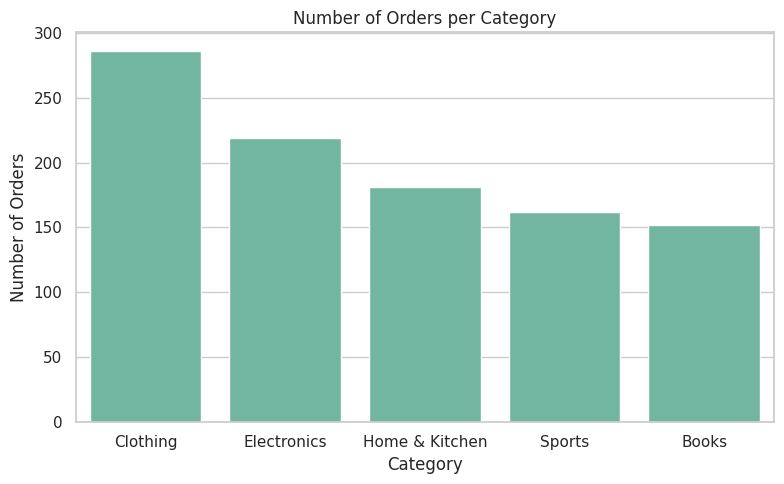

In [10]:
order = df["category"].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="category", order=order)
plt.title("Number of Orders per Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

### Q12. Count Plot with Hue
Number of orders for each `payment_method`, split by `customer_gender`.

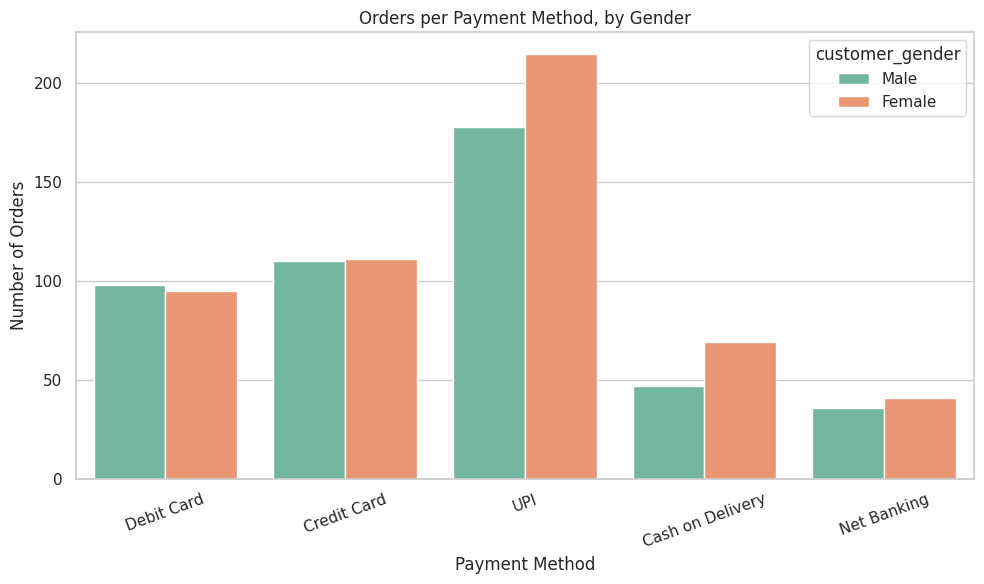

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="payment_method", hue="customer_gender")
plt.title("Orders per Payment Method, by Gender")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Q13. Bar Plot: Average Revenue by Category

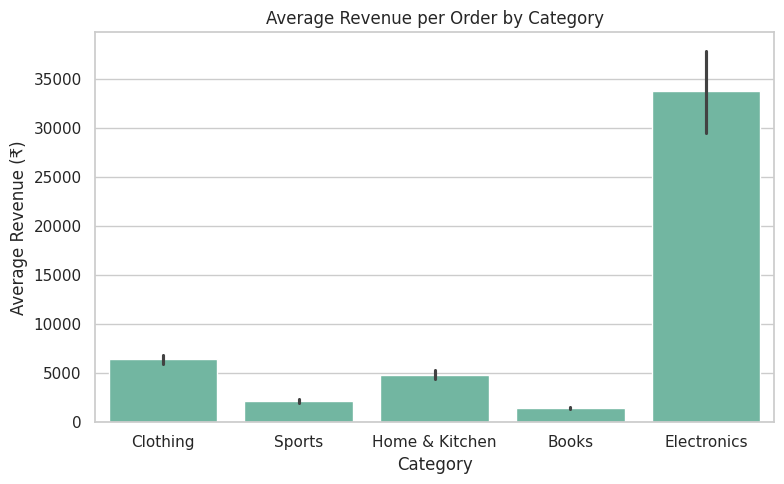

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="category", y="revenue", estimator="mean")
plt.title("Average Revenue per Order by Category")
plt.xlabel("Category")
plt.ylabel("Average Revenue (₹)")
plt.tight_layout()
plt.show()

# The black error bars are the 95% confidence interval around the mean,
# estimated by seaborn via bootstrapping the order-level revenue values
# within each category (NOT standard deviation of the raw data).

### Q14. Horizontal Bar Plot: Profit by Region

/tmp/ipykernel_807/4187159162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="region", x="profit", order=region_order, palette="viridis")


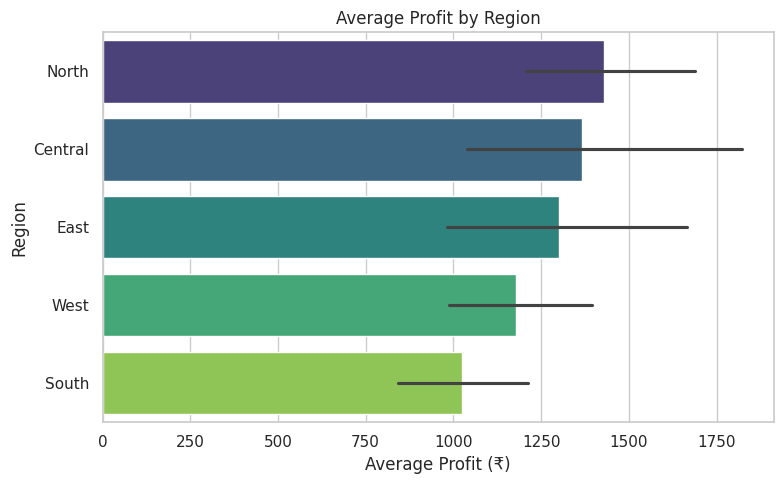

In [13]:
region_order = df.groupby("region")["profit"].mean().sort_values(ascending=False).index

plt.figure(figsize=(8, 5))
sns.barplot(data=df, y="region", x="profit", order=region_order, palette="viridis")
plt.title("Average Profit by Region")
plt.xlabel("Average Profit (₹)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Q15. Box Plot: Ratings by Category

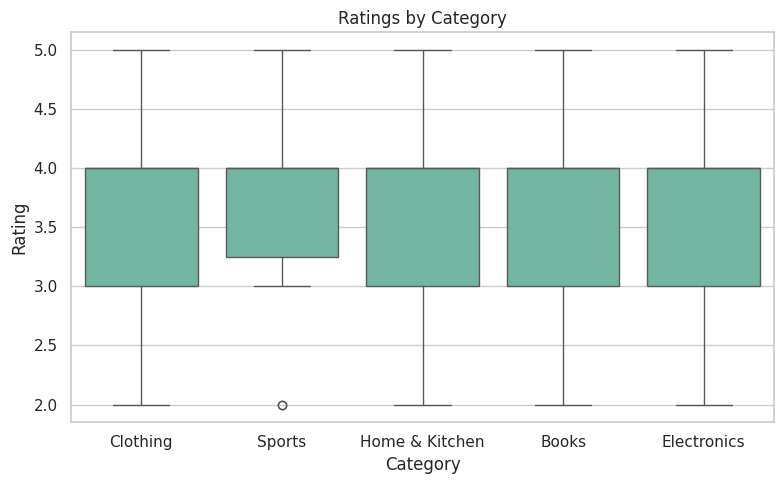

category
Books             4.0
Clothing          4.0
Electronics       4.0
Home & Kitchen    4.0
Sports            4.0
Name: rating, dtype: float64
category
Sports            3.981481
Clothing          3.916084
Books             3.894737
Home & Kitchen    3.872928
Electronics       3.853881
Name: rating, dtype: float64


In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="category", y="rating")
plt.title("Ratings by Category")
plt.xlabel("Category")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

print(df.groupby("category")["rating"].median().sort_values(ascending=False))
print(df.groupby("category")["rating"].mean().sort_values(ascending=False))

# The median rating (4.0) is tied across all five categories, so the boxes
# look almost identical. Looking at the MEAN rating instead, Sports has the
# highest average rating (~3.98), narrowly ahead of Clothing and Books.

### Q16. Violin Plot: Delivery Time by Region

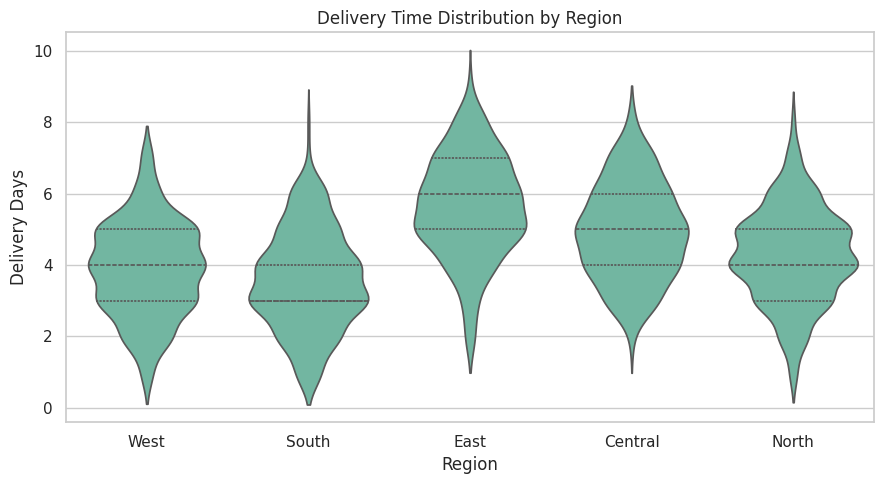

region
East       5.620253
Central    4.944954
North      4.261818
West       3.887850
South      3.577869
Name: delivery_days, dtype: float64


In [15]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="region", y="delivery_days", inner="quartile")
plt.title("Delivery Time Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Delivery Days")
plt.tight_layout()
plt.show()

print(df.groupby("region")["delivery_days"].mean().sort_values(ascending=False))

# East has the slowest deliveries, with the highest mean delivery time
# (~5.6 days), noticeably above every other region.

### Q17. Box Plot + Strip Plot

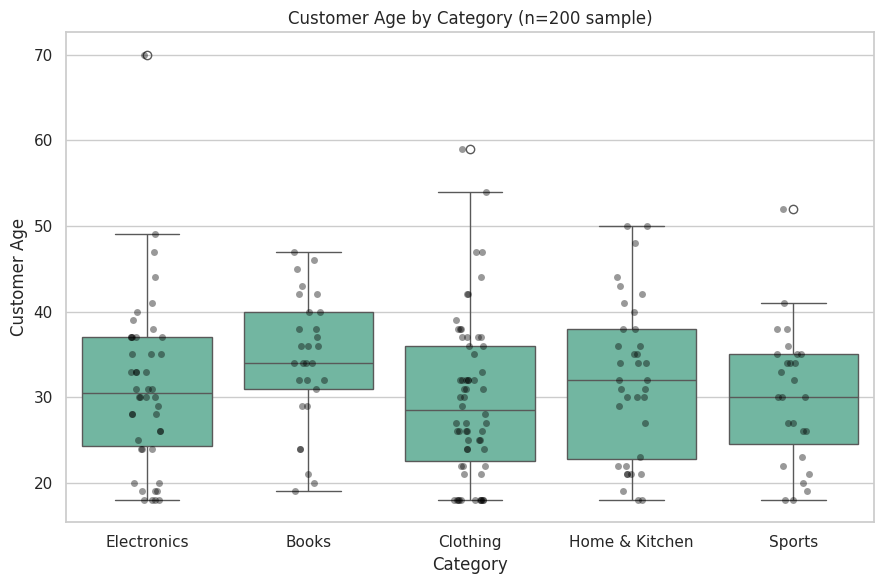

In [16]:
sample = df.sample(200, random_state=1)

plt.figure(figsize=(9, 6))
sns.boxplot(data=sample, x="category", y="customer_age")
sns.stripplot(data=sample, x="category", y="customer_age",
              color="black", alpha=0.4, jitter=True)
plt.title("Customer Age by Category (n=200 sample)")
plt.xlabel("Category")
plt.ylabel("Customer Age")
plt.tight_layout()
plt.show()

### Q18. Point Plot: Average Rating

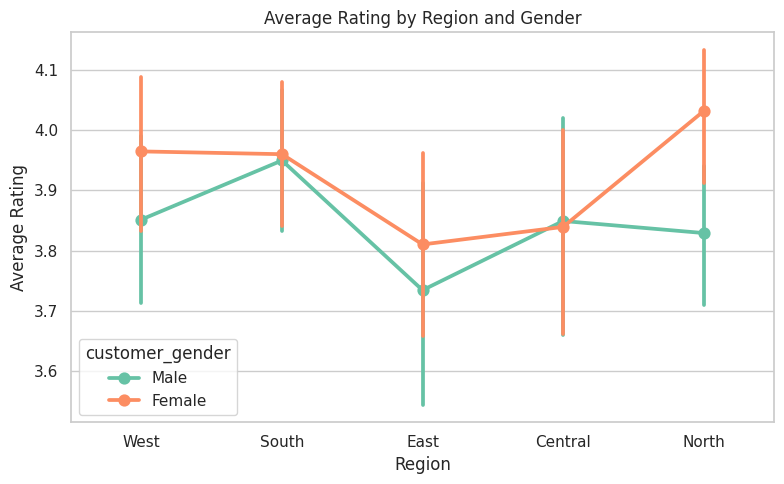

In [17]:
plt.figure(figsize=(8, 5))
sns.pointplot(data=df, x="region", y="rating", hue="customer_gender")
plt.title("Average Rating by Region and Gender")
plt.xlabel("Region")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

### Q19. Histogram with KDE

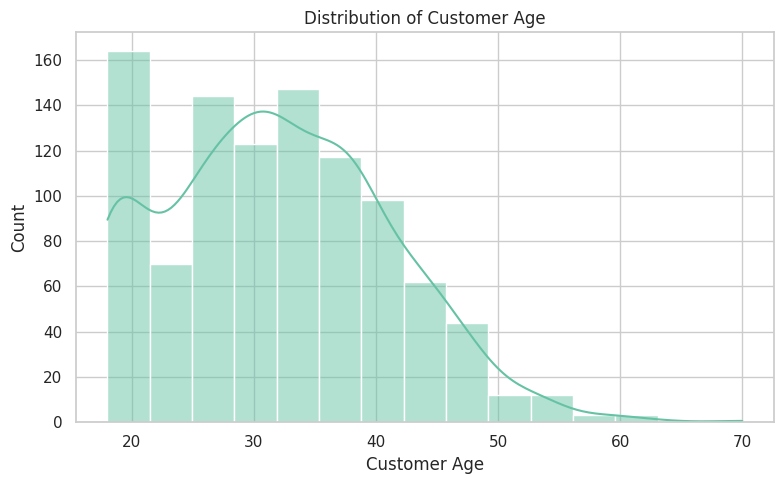

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="customer_age", bins=15, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Q20. Histogram by Group

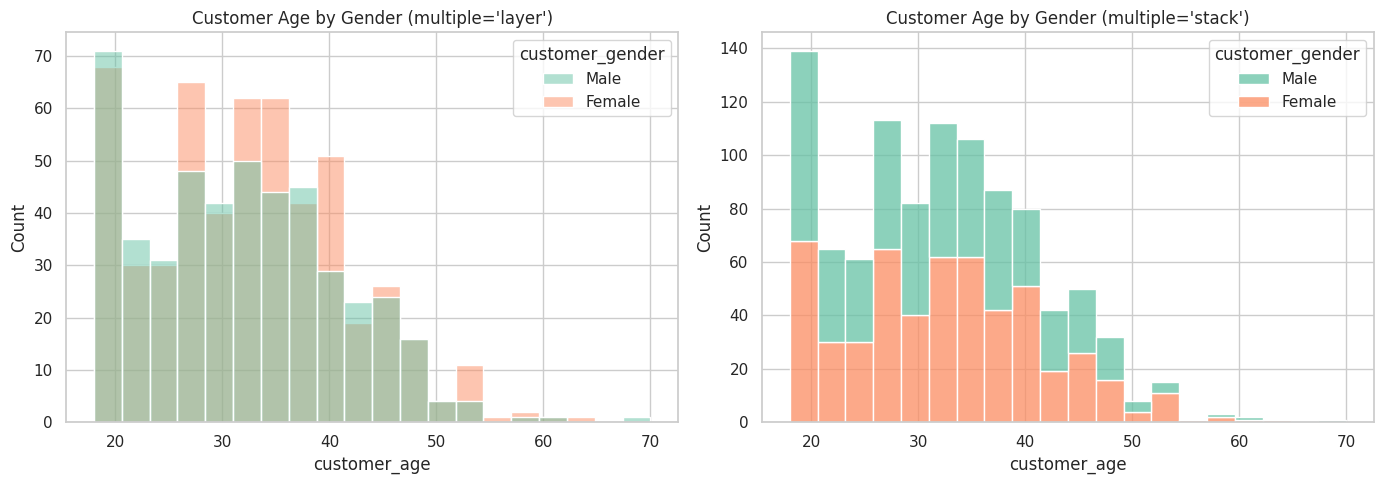

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="customer_age", hue="customer_gender",
             multiple="layer", alpha=0.5, ax=axes[0])
axes[0].set_title("Customer Age by Gender (multiple='layer')")

sns.histplot(data=df, x="customer_age", hue="customer_gender",
             multiple="stack", ax=axes[1])
axes[1].set_title("Customer Age by Gender (multiple='stack')")

plt.tight_layout()
plt.show()

# "layer" overlays the two histograms with transparency, so overlapping bins
# blend together and you can compare the two shapes directly at every age.
# "stack" instead places one group's bars on top of the other's, so bar
# heights show the combined total per bin, but it's harder to compare the
# two individual distributions' shapes since only the stacked segment (not
# a shared baseline) represents each group.

### Q21. KDE Plot

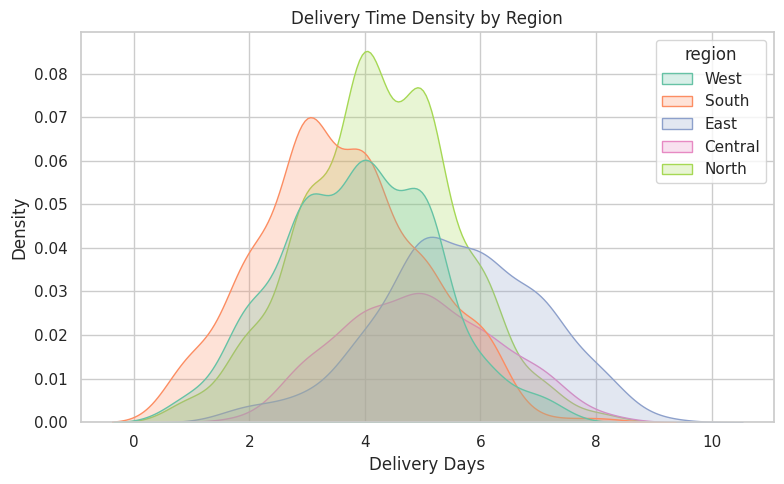

             mean       std
region                     
Central  4.944954  1.311169
East     5.620253  1.407928
North    4.261818  1.311306
South    3.577869  1.375148
West     3.887850  1.309604


In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="delivery_days", hue="region", fill=True)
plt.title("Delivery Time Density by Region")
plt.xlabel("Delivery Days")
plt.tight_layout()
plt.show()

print(df.groupby("region")["delivery_days"].agg(["mean", "std"]))

# South and West have the most similar distributions: their means
# (~3.58 and ~3.89 days) and spreads (std ~1.38 and ~1.31) are the closest
# of any pair of regions, so their KDE curves overlap the most.

### Q22. Scatter Plot

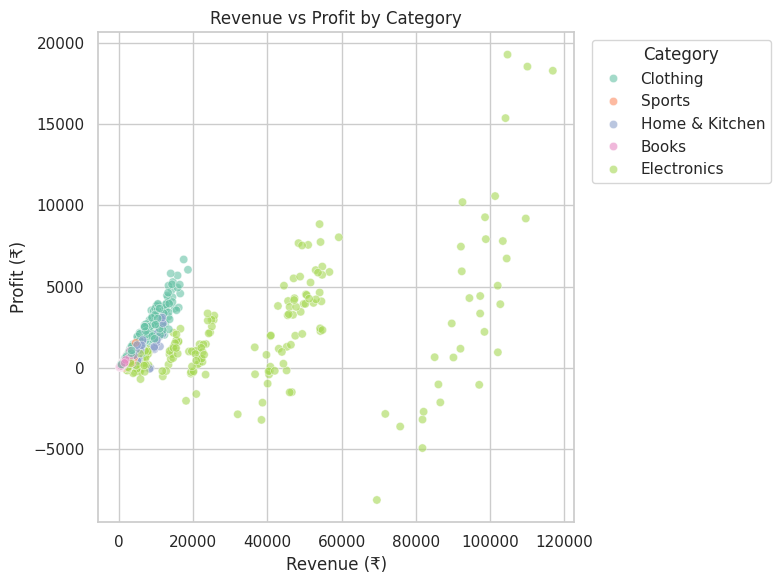

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="revenue", y="profit", hue="category", alpha=0.6)
plt.title("Revenue vs Profit by Category")
plt.xlabel("Revenue (₹)")
plt.ylabel("Profit (₹)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Category")
plt.tight_layout()
plt.show()

### Q23. Regression Plot

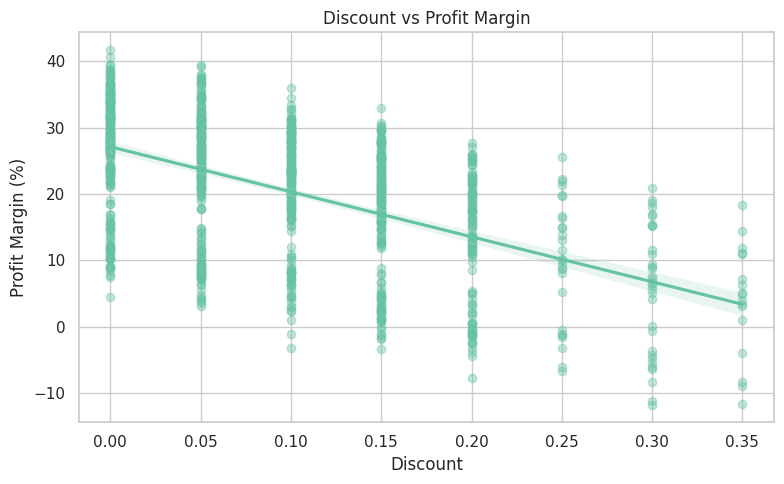

-0.5481495219075037


In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="discount", y="profit_margin",
            scatter_kws={"alpha": 0.4})
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

print(df["discount"].corr(df["profit_margin"]))

# The relationship is negative (correlation ≈ -0.55): larger discounts are
# associated with lower profit margins, as expected since discounting
# directly eats into the margin on each order.

### Q24. Line Plot with Hue

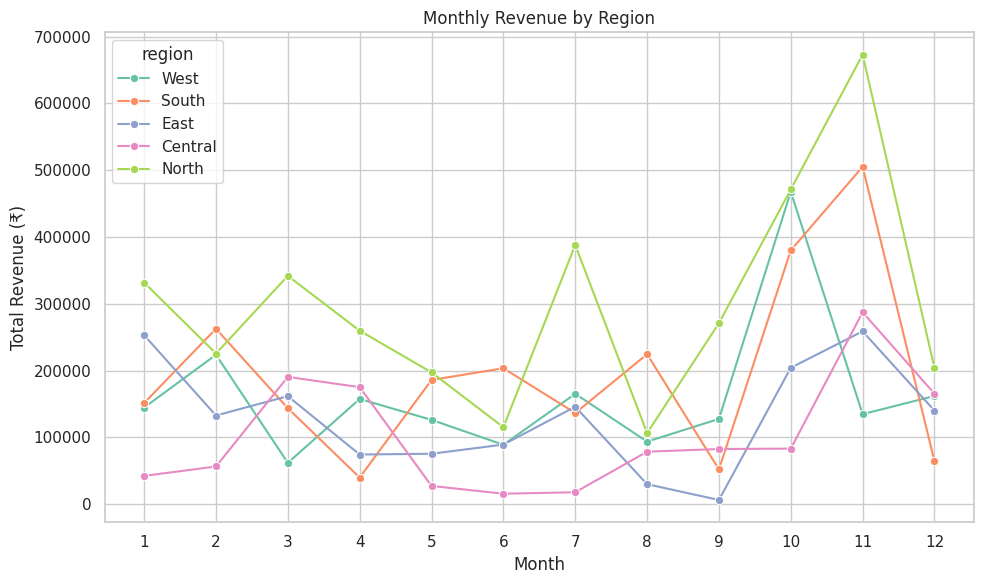

In [23]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="month", y="revenue", hue="region",
             estimator="sum", errorbar=None, marker="o")
plt.title("Monthly Revenue by Region")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Q25. Heatmap: Correlation Matrix

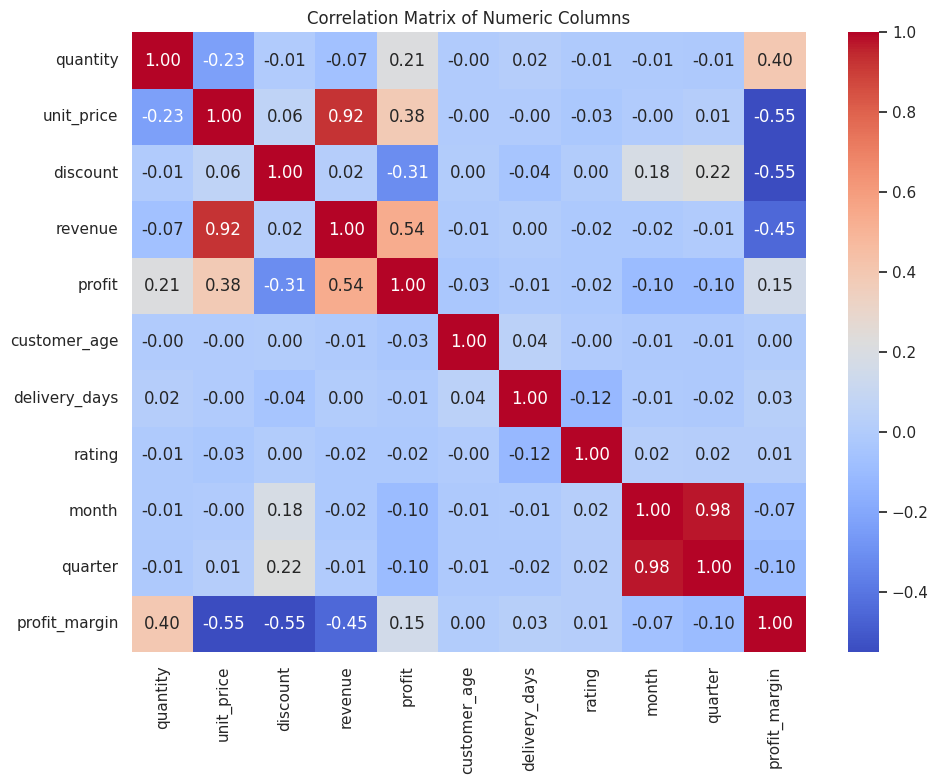

In [24]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Columns")
plt.tight_layout()
plt.show()

# The two most strongly correlated pairs (excluding a column with itself):
#   1) unit_price & revenue   (r ≈ 0.92) — higher-priced items drive higher
#      order revenue, as expected since revenue is derived from unit_price.
#   2) revenue & profit       (r ≈ 0.54) — orders with more revenue tend
#      to generate more profit, though the relationship is only moderate.

### Q26. Heatmap: Pivot Table

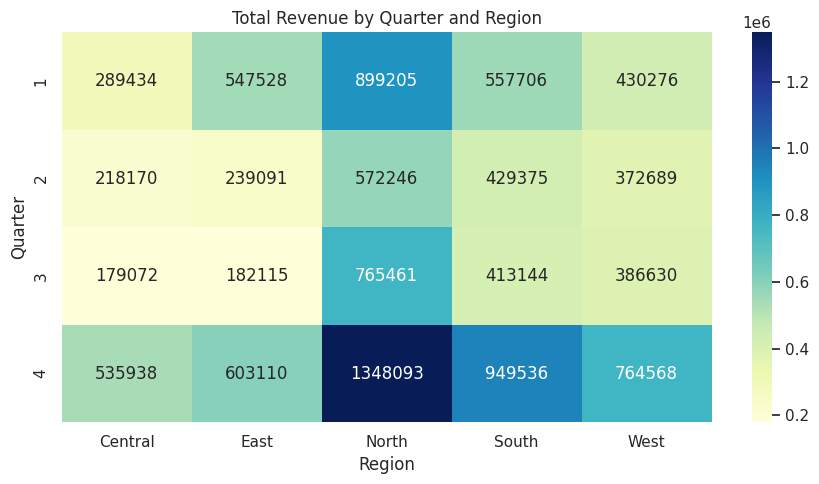

In [25]:
pivot = df.pivot_table(values="revenue", index="quarter",
                        columns="region", aggfunc="sum")

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Total Revenue by Quarter and Region")
plt.xlabel("Region")
plt.ylabel("Quarter")
plt.tight_layout()
plt.show()

### Q27. Joint Plot

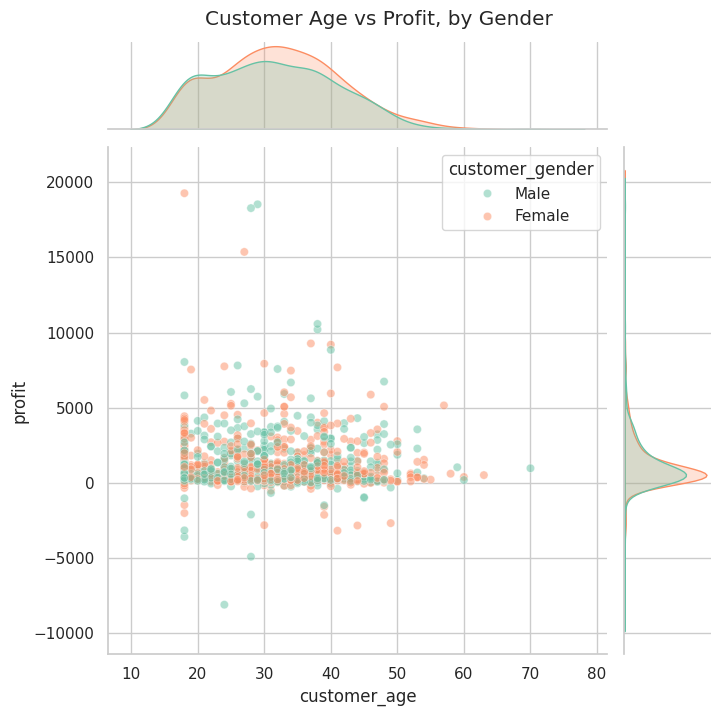

In [26]:
sns.jointplot(data=df, x="customer_age", y="profit",
              hue="customer_gender", alpha=0.5, height=7)
plt.suptitle("Customer Age vs Profit, by Gender", y=1.02)
plt.show()

# The marginal plots on top and right show the individual (univariate)
# distributions of customer_age and profit respectively, split by gender —
# they let you see each variable's spread/shape on its own, separate from
# how the two variables relate to each other in the central scatter plot.

### Q28. Pair Plot

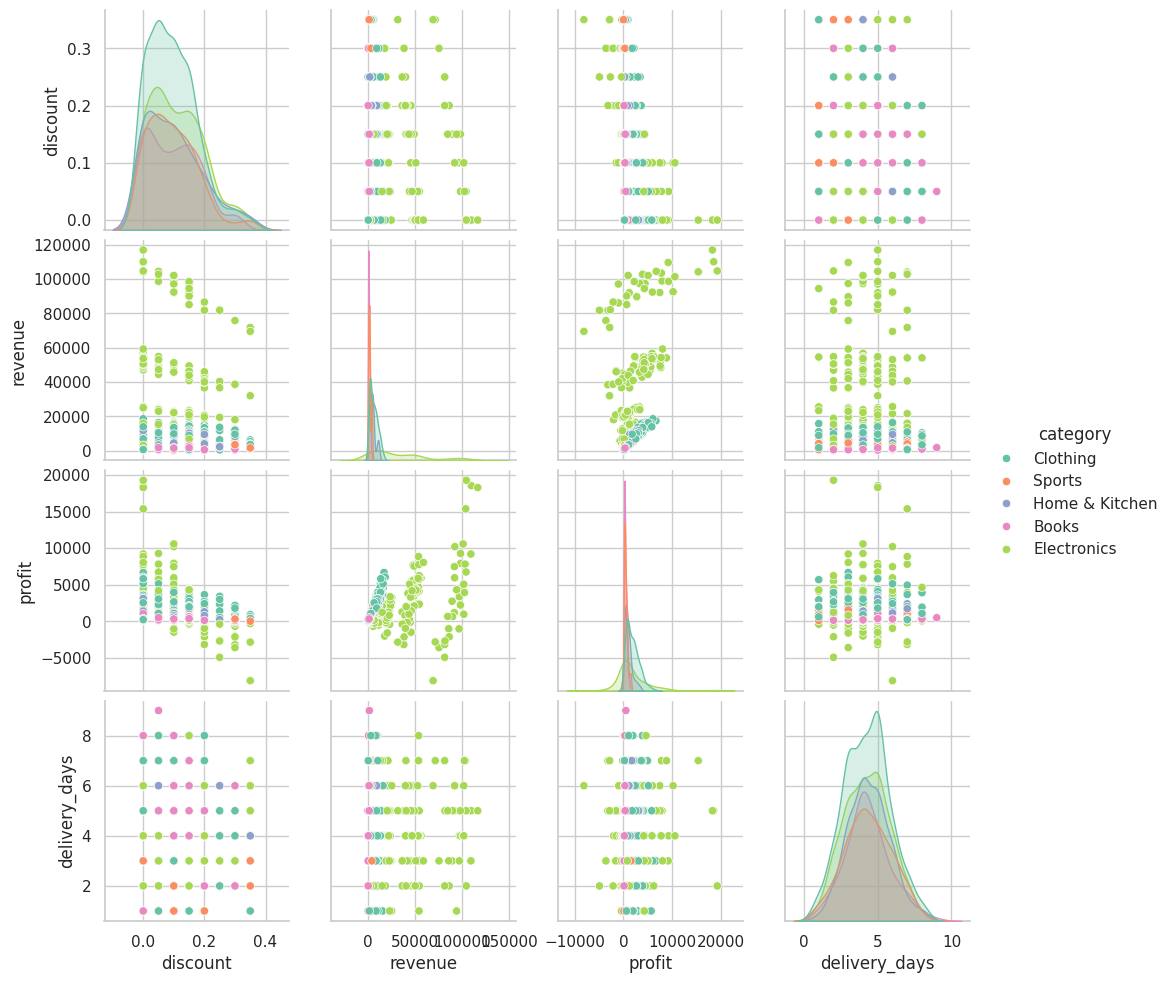

In [27]:
cols = ["discount", "revenue", "profit", "delivery_days", "category"]

sns.pairplot(df[cols], hue="category", diag_kind="kde")
plt.show()

# revenue and profit show the clearest pattern: they trend upward together
# (a positive, roughly linear-looking relationship), consistent with the
# ~0.54 correlation seen in the Q25 heatmap.

### Q29. Faceted Bar Plots

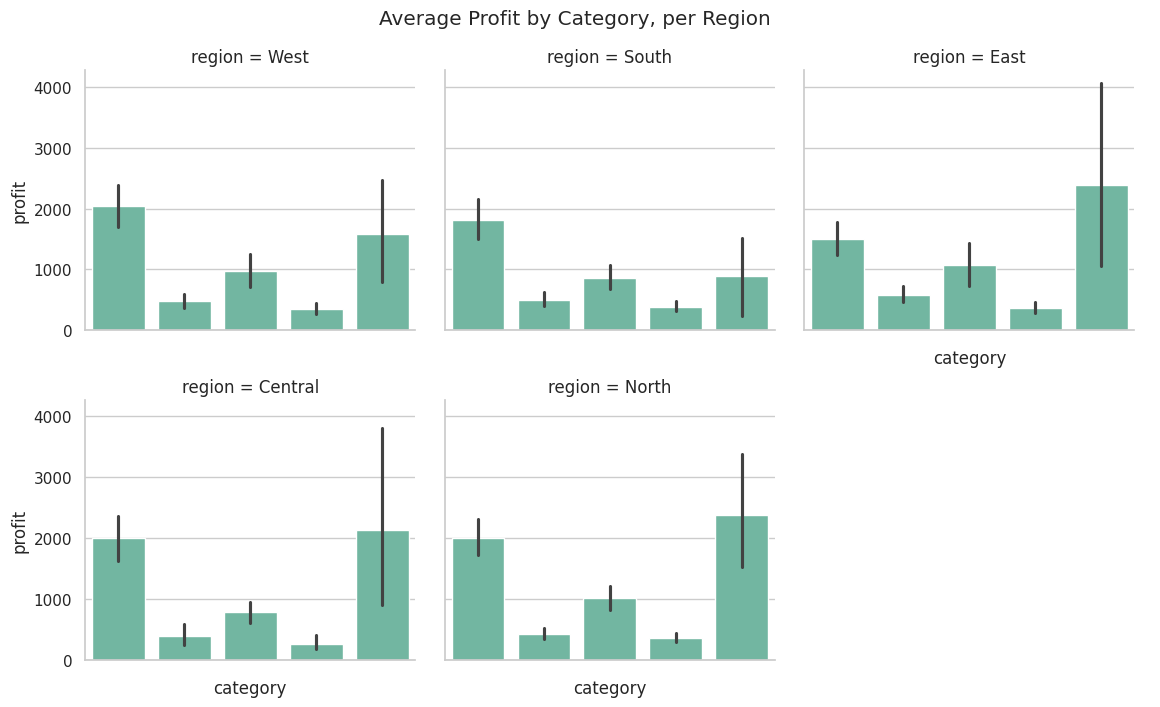

In [28]:
g = sns.catplot(data=df, kind="bar", x="category", y="profit",
                 col="region", col_wrap=3, height=3.5, aspect=1.1)
g.set_xticklabels(rotation=45, ha="right")
g.fig.suptitle("Average Profit by Category, per Region", y=1.03)
plt.show()

### Q30. Mini Dashboard

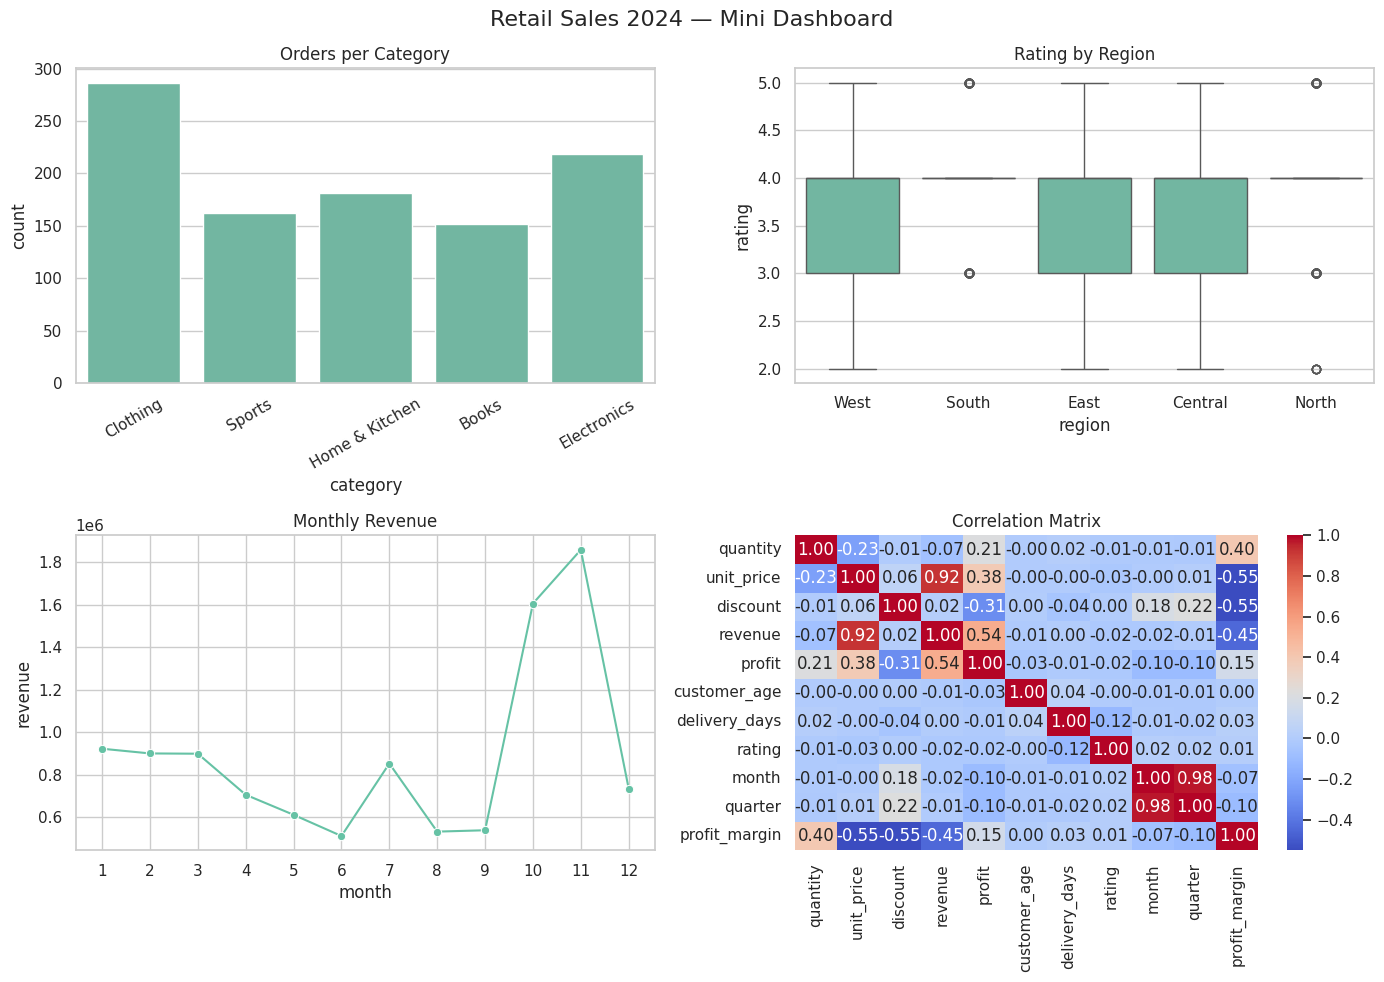

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: countplot of category
sns.countplot(data=df, x="category", ax=axes[0, 0])
axes[0, 0].set_title("Orders per Category")
axes[0, 0].tick_params(axis="x", rotation=30)

# Top-right: boxplot of rating by region
sns.boxplot(data=df, x="region", y="rating", ax=axes[0, 1])
axes[0, 1].set_title("Rating by Region")

# Bottom-left: lineplot of monthly revenue
monthly_revenue = df.groupby("month")["revenue"].sum().reset_index()
sns.lineplot(data=monthly_revenue, x="month", y="revenue", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Monthly Revenue")
axes[1, 0].set_xticks(range(1, 13))

# Bottom-right: heatmap of the correlation matrix (numeric columns)
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

fig.suptitle("Retail Sales 2024 — Mini Dashboard", fontsize=16)
plt.tight_layout()
plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")
plt.show()